##  서울시 자치구 서대문구에서 치킨집이 가장 많은 동은 어디인가?

### 자료 출처
- 데이터 다운로드 :  LOCALDATA  웹사이트
- http://www.localdata.kr
- 지방자치단체에서 인/허가한 업종별 데이터 제공
- 문화, 체육, 관광, 식품 등 11가지 분야에 대한 데이터 제공
- 회원 가입 절차를 별도로 거치지 않고도 공공데이터 다운로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 한글 문제
# matplotlit의 기본 폰트에서 한글 지원되지 않기 때문에
# matplotlib의 폰트 변경 필요
import platform

from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':  # 맥OS 
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # 윈도우
    path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system...  sorry~~~')


In [3]:
# 서울 특별시_일반음식점.csv 사용
# data=pd.read_csv('./data/서울특별시_일반음식점.csv')
#UnicodeDecodeError - 인코딩에러
#'utf-8' codec can't decode byte 0xb9 in position 1: invalid start byte

In [4]:
data=pd.read_csv('./data/서울특별시_일반음식점.csv',
                       encoding='cp949',
                       low_memory=False)

In [5]:
# data 확인
data.head(2)
data.tail(2)

,번호,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,...,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지,Unnamed: 47
472913,472914,일반음식점,07_24_04_P,3150000,3150000-101-2021-00072,20210203,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,75.60,NaN,NaN,NaN,NaN
472914,472915,일반음식점,07_24_04_P,3130000,3130000-101-2020-01013,20201208,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,22.75,NaN,NaN,NaN,NaN


In [6]:
#  데이터 개요(일반정보) 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472915 entries, 0 to 472914
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   번호           472915 non-null  int64  
 1   개방서비스명       472915 non-null  object 
 2   개방서비스아이디     472915 non-null  object 
 3   개방자치단체코드     472915 non-null  int64  
 4   관리번호         472915 non-null  object 
 5   인허가일자        472915 non-null  int64  
 6   인허가취소일자      0 non-null       float64
 7   영업상태구분코드     472915 non-null  int64  
 8   영업상태명        472915 non-null  object 
 9   상세영업상태코드     472915 non-null  int64  
 10  상세영업상태명      472915 non-null  object 
 11  폐업일자         348707 non-null  float64
 12  휴업시작일자       0 non-null       float64
 13  휴업종료일자       0 non-null       float64
 14  재개업일자        0 non-null       float64
 15  소재지전화        327325 non-null  object 
 16  소재지면적        439015 non-null  object 
 17  소재지우편번호      472670 non-null  float64
 18  소재지전체주소      472678 non-

### 각 인허가된 점포가 취급하는 품목이 무엇인지? 음식점이면서 치킨과 관련된 항목을 취급해야 함(위생업태명, 업태구분)
### 현재 영업중인지? (영업상태)
### 주소가 서대문구인지? (도로명 전체주소/소재지 전체주소)

In [7]:
# 각 인허가된 점포가 취급하는 품목이 무엇인지? 음식점이면서 치킨과 관련된 항목을 취급해야 함(위생업태명, 업태구분)
data.위생업태명 # 상세구분
data.업태구분명 # 위생업태명의 상위구분

0         한식
1         한식
2         한식
3         한식
4         일식
          ..
472910    한식
472911    한식
472912    기타
472913    한식
472914    기타
Name: 업태구분명, Length: 472915, dtype: object

In [8]:
# 현재  data 의 위생업태 종류 확인 - 중복 제거 후 한번씩만 표현
# 파이썬 자료구조 중  set :  중복을 허가하지 않는 집합자료형
# 보통 중복 제거 후 data  확인 시 많이 사용
set(data.위생업태명.values)
# 치킨집에 해당하는 data만 필요하므로  치킨/통닭 두 단어중 하나를 포함한 위생업태명의 
# 점포  data만 사용

{nan,
 '간이주점',
 '감성주점',
 '경양식',
 '기타',
 '기타 휴게음식점',
 '김밥(도시락)',
 '까페',
 '냉면집',
 '다방',
 '라이브카페',
 '룸살롱',
 '복어취급',
 '분식',
 '뷔페식',
 '식육(숯불구이)',
 '식품등 수입판매업',
 '식품소분업',
 '외국음식전문점(인도,태국등)',
 '이동조리',
 '일반조리판매',
 '일식',
 '전통찻집',
 '정종/대포집/소주방',
 '제과점영업',
 '중국식',
 '출장조리',
 '커피숍',
 '키즈카페',
 '탕류(보신용)',
 '통닭(치킨)',
 '패밀리레스트랑',
 '패스트푸드',
 '한식',
 '호프/통닭',
 '횟집'}

In [9]:
# 위생업태명에 통닭이나 치킨 문자열이 포함되어 있는지 확인
# 문자열.contains(확인하려는 문자열1,na=False) : 
# 문자열안에 문자열1이 포함되어 있는지의 여부 : T/F로 반환
data.위생업태명.str.contains('통닭|치킨',na=False)

0         False
1         False
2         False
3         False
4         False
          ...  
472910    False
472911    False
472912    False
472913    False
472914    False
Name: 위생업태명, Length: 472915, dtype: bool

In [10]:
# 조건 인덱싱을 사용 : 위생업태명 중 통닭/치킨이 포함된 업태명 반환
data.위생업태명[data.위생업태명.str.contains('통닭|치킨',na=False)]
set(data.위생업태명[data.위생업태명.str.contains('통닭|치킨',na=False)])
# 위생 업태명이 {'통닭(치킨)', '호프/통닭'}인 업장  data가 필요

{'통닭(치킨)', '호프/통닭'}

In [11]:
# 현재 영업중인 업장
set(data.영업상태명.values)

{'영업/정상', '폐업'}

- 영업상태명이 영업/정상 이고 위생 업태명이 '통닭(치킨)', '호프/통닭'인 업장 data 추출

In [12]:
# 위 조건을 만족하는 조건식 생성
# 시리즈.isin([데이터1, 데이터2,...])
# 시리즈 원소가 집합형자료(list 등)의 적어도 원소 1개와 일치하면 True반환해주는 함수
(data.영업상태명=='영업/정상') &  (data.위생업태명.isin(['통닭(치킨)', '호프/통닭']))

0         False
1         False
2         False
3         False
4         False
          ...  
472910    False
472911    False
472912    False
472913    False
472914    False
Length: 472915, dtype: bool

In [13]:
# datad_fin : 서울시에서 현재 영업중인 치킨집 정보가 저장된 변수
data_fin = data[(data.영업상태명=='영업/정상') &  (data.위생업태명.isin(['통닭(치킨)', '호프/통닭']))]

In [14]:
data_fin.info()
# 서울시 전체 자치구의 현재 영업중인 치킨집의 수는 13100개임

<class 'pandas.core.frame.DataFrame'>
Index: 13110 entries, 30 to 124203
Data columns (total 48 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   번호           13110 non-null  int64  
 1   개방서비스명       13110 non-null  object 
 2   개방서비스아이디     13110 non-null  object 
 3   개방자치단체코드     13110 non-null  int64  
 4   관리번호         13110 non-null  object 
 5   인허가일자        13110 non-null  int64  
 6   인허가취소일자      0 non-null      float64
 7   영업상태구분코드     13110 non-null  int64  
 8   영업상태명        13110 non-null  object 
 9   상세영업상태코드     13110 non-null  int64  
 10  상세영업상태명      13110 non-null  object 
 11  폐업일자         0 non-null      float64
 12  휴업시작일자       0 non-null      float64
 13  휴업종료일자       0 non-null      float64
 14  재개업일자        0 non-null      float64
 15  소재지전화        6536 non-null   object 
 16  소재지면적        12677 non-null  object 
 17  소재지우편번호      13103 non-null  float64
 18  소재지전체주소      13103 non-null  object 
 19  도로명전체주소

In [15]:
# 서대문구 데이터만 필요 : 주소컬럼 사용
data_fin = data_fin[['소재지전체주소','위생업태명']]
data_fin.head()

,소재지전체주소,위생업태명
30,서울특별시 은평구 갈현동 400-9번지 (지하1층),호프/통닭
43,서울특별시 영등포구 양평동3가 101번지 현대아파트 상가내 1층 102호,호프/통닭
44,서울특별시 중구 필동2가 32-24번지 1층,호프/통닭
66,서울특별시 종로구 당주동 128-17번지 (지상1층),호프/통닭
67,서울특별시 서초구 우면동 59번지 105호,호프/통닭


In [16]:
# 위생업태명 유효성 검사
set(data_fin.위생업태명)

{'통닭(치킨)', '호프/통닭'}

In [17]:
# 주소컬럼 이용 서대문구 data만 추출
# 주소에 서대문구 문자열이 포함된 행만 추출
res = data_fin.소재지전체주소.str.contains('서대문구',na=False)
data_seo = data_fin[res]
data_seo.head()

,소재지전체주소,위생업태명
178,서울특별시 서대문구 창천동 33-25번지,통닭(치킨)
698,서울특별시 서대문구 홍제동 459 현대종합상가,호프/통닭
724,서울특별시 서대문구 남가좌동 347-20번지,호프/통닭
1200,서울특별시 서대문구 연희동 131-1번지 사러가쇼핑,호프/통닭
1405,서울특별시 서대문구 창천동 52-14,호프/통닭


- data_seo df은 서대문구 치킨집의 주소정보를 갖고있는 df

In [18]:
data_seo.info()
# 서대문구 전체 치킨집수는 400개

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 178 to 124130
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   소재지전체주소  400 non-null    object
 1   위생업태명    400 non-null    object
dtypes: object(2)
memory usage: 9.4+ KB


### 서대문구 각 동의 치킨집 수를 연산
- 동 정보는 주소에 있음(주소는 규칙이 있음)
    - ex. 서울특별시 서대문구 연희동 131-1번지 사러가쇼핑
        - 앞 5글자 : 광역시도
        - 공백
        - 4글자 : 자치구
        - 공백
        - 서대문구 주소는  11글자를 skip 하면 동정보가 나옴
        - 동데이터는 5글자를 추출 후 불필요한 문자는 제거 후 사용(문자열 전처리)
        - 주소 문자열의 11번 인덱스부터 16인덱스 위치까지 추출
- 문자열 함수 중  slice(start=시작인덱스, stop=끝인덱스 + 1)

In [19]:
addr = data_seo.소재지전체주소.str.slice(start=11, stop=17)
addr

178       창천동 33
698       홍제동 45
724       남가좌동 3
1200      연희동 13
1405      창천동 52
           ...  
122500    남가좌동 3
123490    홍제동 30
123548    홍제동 96
123724    북아현동 1
124130    남가좌동 3
Name: 소재지전체주소, Length: 400, dtype: object

- addr : 서대문구 치킨집의 동 정보
    - 동명 외에 더 많은 문자가 들어 있으므로 전처리
    - 숫자, 공백 제거
- 숫자 제거 : 정규식 활용
    - 정규식 : 일련의 약속된 연산기호를 이용해서 문자열안에서 필요한 문자만 추출하는 연산식
    - 사용용도 : 형식문자 검증할 때 사용(이메일, url 주소, 주민등록번호 등)

In [20]:
import re # 정규식 패키지
# re.sub(정규식, 대체문자, 원문자) : str.replace 와 같은 역활
# 한개의 원소(문자열 1개)에 대해서만 작업함
# 숫자를 의미하는 정규식 : [0-9]+ -> 0-9사이의 문자가 1번이상 반복되는 패턴
re.sub(r'[0-9]+','','창천동 52').replace(' ','')

'창천동'

In [21]:
# addr  변수에는 서대문구 치킨집 주소에서 동이름만 추출한 data가 저장
# 숫자와 공백이 포함되어 있는 data가 있기 때문에 숫자와 공백 제거
# 시리즈에 저장
i=0
addr_fin = pd.Series() # 빈 시리즈 생성
for string in addr : 
    newstring = re.sub(r'[0-9]+','',string).replace(' ','')
    addr_fin[i] = newstring
    i = i+1

In [22]:
# 숫자와 공백이 제거된 서대문구 동 data
addr_fin # 서대문구의 치진집의 주소 중 동명만 추출한 값을 저장한 변수

0       창천동
1       홍제동
2      남가좌동
3       연희동
4       창천동
       ... 
395    남가좌동
396     홍제동
397     홍제동
398    북아현동
399    남가좌동
Length: 400, dtype: object

In [23]:
# 서대문구 각 동에 치킨집이 몇개나 있는지 확인
# pd.series.value_counts()
addr_fin.value_counts()

창천동     87
홍제동     48
북가좌동    48
남가좌동    47
연희동     40
홍은동     34
충정로가    21
북아현동    20
대현동     15
냉천동     10
홍은동-     9
미근동      6
창천동-     4
옥천동      2
영천동      2
천연동      2
옥천동번     1
대신동      1
합동       1
합동-      1
연희동-     1
Name: count, dtype: int64

In [24]:
addr_fin = addr_fin.str.replace('-','').str.replace('옥천동번','옥천동')

In [25]:
# 전처리가 종료된 최종 data 이용해서 동별로 개수 세기
ck_cnt = addr_fin.value_counts()

In [26]:
#  서울시 서대문구의 각 동별 치킨집 수(치킨집 분포)
ck_cnt

창천동     91
홍제동     48
북가좌동    48
남가좌동    47
홍은동     43
연희동     41
충정로가    21
북아현동    20
대현동     15
냉천동     10
미근동      6
옥천동      3
영천동      2
합동       2
천연동      2
대신동      1
Name: count, dtype: int64

###  tree map 그래프를 활용한 시각화
- heatmap과 비슷한 그래프 : heatmat이 data의 크기를 색상으로 규정하는데 반해
    - treemap은 사각형 내부 조각의 크기를 이용해서 data 크기 표현
    - python treemap :  squarifty 패키지 사용(pip install 해서 사용)

In [27]:
# --user 옵션은 권한 무시
!pip install --user squarify
# 설치 후 주피터 노트북 재 실행 해야 적용될 수 있음

In [28]:
import squarify # 트리맵 작도 패키지

- squarify.plot(데이터,label=표시할라벨data)

In [29]:
ck_cnt.values
ck_cnt.index

Index(['창천동', '홍제동', '북가좌동', '남가좌동', '홍은동', '연희동', '충정로가', '북아현동', '대현동',
       '냉천동', '미근동', '옥천동', '영천동', '합동', '천연동', '대신동'],
      dtype='object')

<Axes: >

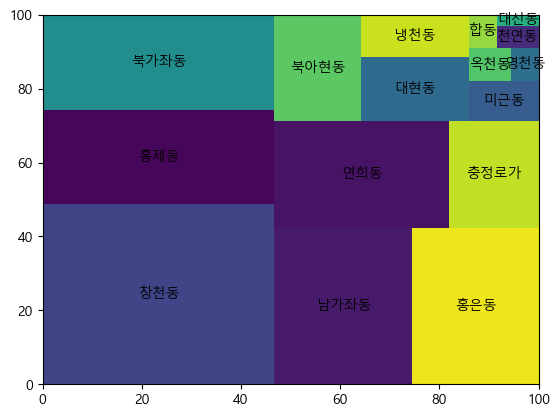

In [30]:
squarify.plot(ck_cnt)
squarify.plot(ck_cnt, label=ck_cnt.index)

### 연습
- 정상영업/폐업 상관없이 현 시점(파일기준) 치킨집의 인허가 분포도(25개 자치구별)
- 영업상태가 폐업인 업장의 자치구별 분포도(업종 일반음식점인 업장)
- 강남구의 읍면동별 중국집 분포도(전체인허가/정상영업/폐업 각각에 대해 시각화)

In [31]:
#  정상영업/폐업 상관없이 현 시점(파일기준) 치킨집의 인허가 분포도(25개 자치구별)
# datad_fin : 서울시에서 현재 영업중인 치킨집 정보가 저장된 변수
data_fin = data[(data.위생업태명.isin(['통닭(치킨)', '호프/통닭']))]

In [32]:
data_fin.head()


,번호,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,...,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지,Unnamed: 47
30,31,일반음식점,07_24_04_P,3110000,3110000-101-1999-06737,19991113,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,60.28,NaN,NaN,NaN,NaN
43,44,일반음식점,07_24_04_P,3180000,3180000-101-2001-14282,20010818,NaN,1,영업/정상,1,...,0.0,NaN,0.0,0,N,12.00,NaN,NaN,NaN,NaN
44,45,일반음식점,07_24_04_P,3010000,3010000-101-2001-13779,20010521,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,28.60,NaN,NaN,NaN,NaN
66,67,일반음식점,07_24_04_P,3000000,3000000-101-2002-11870,20020205,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,41.87,NaN,NaN,NaN,NaN
67,68,일반음식점,07_24_04_P,3210000,3210000-101-2000-15274,20001201,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,19.80,NaN,NaN,NaN,NaN


In [33]:
res = data_fin.소재지전체주소.str.split()
res

30                       [서울특별시, 은평구, 갈현동, 400-9번지, (지하1층)]
43        [서울특별시, 영등포구, 양평동3가, 101번지, 현대아파트, 상가내, 1층, 102호]
44                           [서울특별시, 중구, 필동2가, 32-24번지, 1층]
66                      [서울특별시, 종로구, 당주동, 128-17번지, (지상1층)]
67                            [서울특별시, 서초구, 우면동, 59번지, 105호]
                                ...                        
472851                    [서울특별시, 서대문구, 연희동, 135-5, 1층, 4호]
472857                            [서울특별시, 동대문구, 장안동, 377-9]
472872                  [서울특별시, 강남구, 자곡동, 619, 엘에이치강남힐스테이트]
472888                       [서울특별시, 노원구, 상계동, 593-2, 동원빌딩]
472905    [서울특별시, 강서구, 화곡동, 980-21, 강서아이파크(지하, 1층,, B01-...
Name: 소재지전체주소, Length: 44480, dtype: object

In [34]:
fin_t = []
# print(type(fin_t))
for idx in res.index :
    try :  # 중간에 주소가 없는 데이터가 있음
        a = res.loc[idx][1]
    except : 
        pass
    fin_t.append(a)
#     tmp = res.loc[idx][1]
#     fin.append(res.loc[idx][1])
#     fin.append(res.loc[idx][0])

In [35]:
fin_s = pd.Series(fin_t)
fin_s.value_counts()

마포구     2825
강동구     2792
구로구     2702
양천구     2476
관악구     2370
중랑구     2285
동대문구    2205
영등포구    2161
광진구     2160
은평구     2025
노원구     1823
성북구     1805
송파구     1750
금천구     1712
강북구     1683
강서구     1668
서초구     1623
도봉구     1532
성동구     1510
동작구     1186
강남구     1169
서대문구    1133
중구       718
용산구      641
종로구      525
성남시        1
Name: count, dtype: int64

In [36]:
fin = fin_s.drop(fin_s[fin_s=='성남시'].index).value_counts()

In [37]:
fin.head()

마포구    2825
강동구    2792
구로구    2702
양천구    2476
관악구    2370
Name: count, dtype: int64

<Axes: >

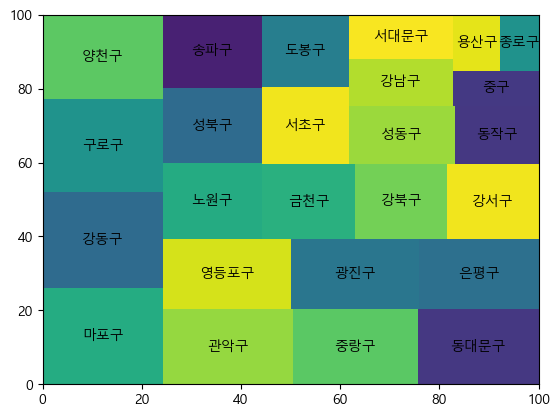

In [38]:
import squarify
squarify.plot(fin)
squarify.plot(fin, label=fin.index)

In [39]:
# 영업상태가 폐업인 업장의 자치구별 분포도(업종 일반음식점인 업장)
data_fin = data[(data.영업상태명=='폐업')]

In [40]:
set(data_fin.영업상태명)

{'폐업'}

In [41]:
res = data_fin.소재지전체주소.str.split()
res

124208                    [서울특별시, 강남구, 삼성동, 157-18]
124209                       [서울특별시, 강남구, 논현동, 8-9]
124210                    [서울특별시, 광진구, 중곡동, 118-34]
124211         [서울특별시, 광진구, 구의동, 591-22, 강변리버빌101호]
124212             [서울특별시, 강남구, 압구정동, 429, 현대백화점본점]
                            ...                    
472910                    [서울특별시, 강남구, 역삼동, 799-18]
472911               [서울특별시, 강남구, 역삼동, 668-9, 해석빌딩]
472912                [서울특별시, 강남구, 논현동, 108, 논현웰스톤]
472913    [서울특별시, 강서구, 마곡동, 798-6, 류마타워Ⅱ, 3층, 310호]
472914                    [서울특별시, 마포구, 망원동, 435-34]
Name: 소재지전체주소, Length: 348707, dtype: object

In [42]:
fin_t = []
# print(type(fin_t))
for idx in res.index :
    try :  # 중간에 주소가 없는 데이터가 있음
        a = res.loc[idx][1]
    except : 
        pass
    fin_t.append(a)

In [43]:
fin_s = pd.Series(fin_t)
fin_s.value_counts()

강남구     31820
송파구     19769
서초구     18945
영등포구    17473
마포구     17024
강동구     17007
동대문구    15650
관악구     15601
강서구     14221
구로구     13631
중구      13481
양천구     12947
서대문구    12552
성북구     12290
중랑구     12240
강북구     11917
은평구     11856
광진구     11796
종로구     11594
노원구     10743
동작구      9899
금천구      9313
용산구      9186
성동구      9105
도봉구      8641
성남시         2
고양시         2
제주시         1
수영구         1
Name: count, dtype: int64

In [44]:
tmp = []
for s in fin_s : 
    tmp.append(s not in ['성남시','고양시','제주시','수영구'])
fin = fin_s[tmp].value_counts()

In [50]:
fin

강남구     31820
송파구     19769
서초구     18945
영등포구    17473
마포구     17024
강동구     17007
동대문구    15650
관악구     15601
강서구     14221
구로구     13631
중구      13481
양천구     12947
서대문구    12552
성북구     12290
중랑구     12240
강북구     11917
은평구     11856
광진구     11796
종로구     11594
노원구     10743
동작구      9899
금천구      9313
용산구      9186
성동구      9105
도봉구      8641
Name: count, dtype: int64

<Axes: >

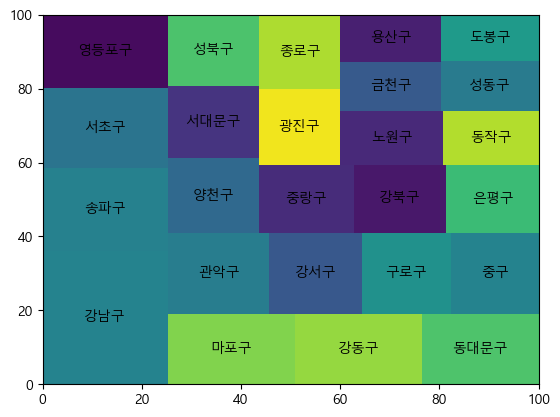

In [45]:
import squarify
squarify.plot(fin)
squarify.plot(fin, label=fin.index)

In [46]:
!pip install folium

     ---------------------------------------- 0.0/102.3 kB ? eta -:--:--
     ----------- ------------------------- 30.7/102.3 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 102.3/102.3 kB 1.5 MB/s eta 0:00:00


In [47]:
import folium

In [49]:
#한국 지도 데이터 이용해서 단계 구분도 그리기
import json
#한국지도 경계의 json data 파일 가져오기
#한글이 포함된경우에는 그냥 path만 연결하면 인코딩 문제 발생
#json.load( encoding='utf-8') 이용해서 변수에 data 저장 후 사용하는 것이 일반적

geo_path = './data/02. skorea_municipalities_geo_simple.json'
geo_str = json.load(open(geo_path,encoding='utf-8'))
# geo_str

#서울을 중심으로 기본 지도 출력
#위경도[37.5502,126.982]
map=folium.Map(location=[37.5502,126.982],
              zoom_start=11,
              tiles='Stamen Toner')
map

In [51]:
map.choropleth(geo_data=geo_str,
               data=fin,
               columns=[fin.index,fin],
               key_on='feature.id',
               fill_color='PuRd',
               legend_name='폐업현황')
folium.LayerControl().add_to(map)
map

C:\Users\USER\anaconda3\Lib\site-packages\folium\folium.py:465: FutureWarning: The choropleth  method has been deprecated. Instead use the new Choropleth class, which has the same arguments. See the example notebook 'GeoJSON_and_choropleth' for how to do this.
  warnings.warn(


#### 강남구의 읍면동별 중국집 분포도(전체인허가/정상영업/폐업 각각에 대해 시각화)

In [117]:
# 강남구 데이터만 필요 : 주소컬럼 사용
data_fin = data[['소재지전체주소','위생업태명','영업상태명']]
data_fin.head()

,소재지전체주소,위생업태명,영업상태명
0,서울특별시 강서구 마곡동 757 두산더랜드파크 B동 207호,한식,영업/정상
1,서울특별시 강서구 화곡동 827-2 1층,한식,영업/정상
2,서울특별시 강남구 역삼동 707-34 한신인터밸리24빌딩,한식,영업/정상
3,서울특별시 강남구 대치동 896-28,한식,영업/정상
4,서울특별시 강남구 삼성동 159-7 현대백화점,일식,영업/정상


In [118]:
set(data_fin[data_fin.위생업태명.str.contains('중국',na=False)].위생업태명)

{'중국식'}

In [119]:
data_fin.shape

(472915, 3)

In [120]:
tmp = []
for s in data_fin.소재지전체주소.str.split() : 
    try : 
        tmp.append(s[1]=='강남구')
    except : 
        tmp.append(False)

In [121]:
len(tmp)

472915

In [134]:
data_gangnam = data_fin[tmp]

In [135]:
data_gangnam.tail()

,소재지전체주소,위생업태명,영업상태명
472902,서울특별시 강남구 역삼동 836-69 MARK TOWER,한식,폐업
472903,서울특별시 강남구 논현동 225-6 논현 아이파크,한식,폐업
472910,서울특별시 강남구 역삼동 799-18,한식,폐업
472911,서울특별시 강남구 역삼동 668-9 해석빌딩,한식,폐업
472912,서울특별시 강남구 논현동 108 논현웰스톤,기타,폐업


In [123]:
# 영업 상태 상관 없는 강남구 중국집 추출
data_jung = data_gangnam[data_gangnam.위생업태명.str.contains('중국',na=False)]

In [127]:
# 정상 영업 강남구 중국집
data_jung_1 = data_gangnam[(data_gangnam.영업상태명=='영업/정상') &  (data_gangnam.위생업태명.str.contains('중국',na=False))]

In [128]:
data_jung_1.head()

,소재지전체주소,위생업태명,영업상태명
1036,서울특별시 강남구 대치동 897-8,중국식,영업/정상
1490,서울특별시 강남구 신사동 541-13번지,중국식,영업/정상
1999,서울특별시 강남구 논현동 58-2번지 마일스디오빌,중국식,영업/정상
2000,서울특별시 강남구 삼성동 159-8번지 파르나스타워,중국식,영업/정상
8612,서울특별시 강남구 대치동 894,중국식,영업/정상


In [129]:
set(data_jung_1.영업상태명)

{'영업/정상'}

In [130]:
data_jung_2 = data_gangnam[(data_gangnam.영업상태명=='폐업') &  (data_gangnam.위생업태명.str.contains('중국',na=False))]

In [131]:
set(data_jung_2.영업상태명)

{'폐업'}

In [139]:
def dong(clm) :
    tmp = []
    for s in clm.소재지전체주소.str.split() : 
        try : 
            tmp.append(s[2])
        except : 
            pass
    return tmp
    

In [144]:
fin = pd.Series(dong(data_jung)).value_counts()

<Axes: >

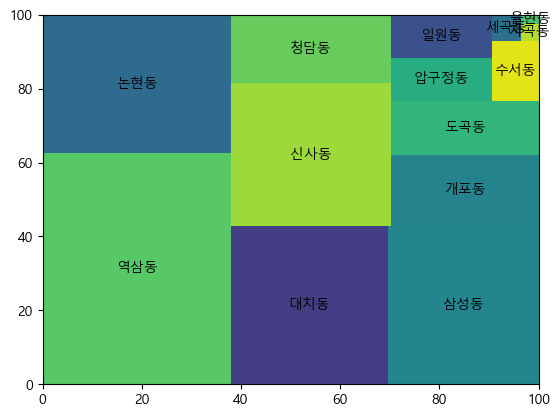

In [145]:
import squarify
squarify.plot(fin)
squarify.plot(fin, label=fin.index)

In [146]:
fin = pd.Series(dong(data_jung_1)).value_counts()

<Axes: >

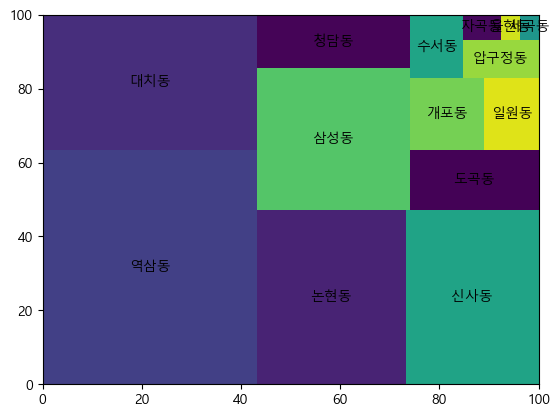

In [147]:
import squarify
squarify.plot(fin)
squarify.plot(fin, label=fin.index)

In [148]:
fin = pd.Series(dong(data_jung_2)).value_counts()

<Axes: >

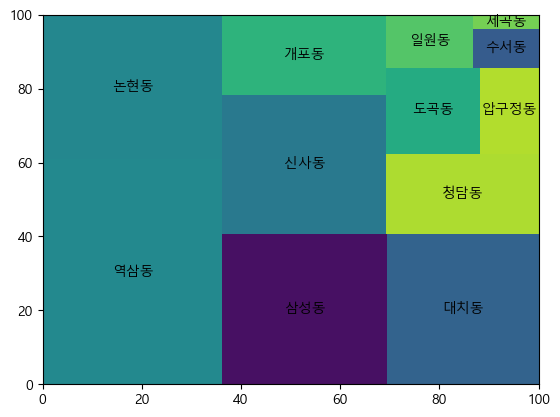

In [149]:
import squarify
squarify.plot(fin)
squarify.plot(fin, label=fin.index)